Seed Manipulation Load Forecasting Linear Regression

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
os.chdir("../..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)

In [2]:
import os 
os.getcwd()

'/home/ortild/Amaranth/opensourcegridmodeling'

Loading and Preprocessing Data

In [3]:
# Download Data
full_df = pd.read_csv('ElectricityDemandAustinTX/LoadForecastingAttacks/full_data.csv', parse_dates=['time'], index_col=['time'])
#full_df.head(5)

In [4]:
# Calculates normalized hourly residuals
hourly_res_norm = ForecastingHelpers.hourlyresiduals(full_df)

/home/ortild/Amaranth/opensourcegridmodeling/ElectricityDemandAustinTX/LoadForecastingAttacks/HelpingFunctions/ForecastingHelpers.py:74: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  hourly_res_norm['load'] = df_norm['load'].groupby(pd.Grouper(freq='M')).transform(lambda x: x - x.mean())


In [5]:
# train-validate-test split
train = hourly_res_norm[:'2014']
validate = hourly_res_norm['2015':'2016']
test = hourly_res_norm['2017':]

# setup training variables 
exog_tr = train.iloc[:,1:].values
ar_tr = train['load'].shift().bfill().values[:,None]
X_tr = np.hstack([ar_tr, exog_tr])
y_tr = train['load'].values

# setup validation variables
exog_val = validate.iloc[:,1:].values
y_val = validate['load'].values

# setup testing variables
exog_te = test.iloc[:,1:].values
ar_test = test['load'].shift().bfill().values[:,None]
y_test = test['load'].values
X_test = np.hstack([ar_test, exog_te])

# setup miscellaneous variables
yp_full = hourly_res_norm.loc[:'2016','load']
yp_val = hourly_res_norm.loc['2015':'2016','load']
yp_te = hourly_res_norm.loc['2017':,'load']
y_init_val = np.hstack([y_tr[-1], validate.iloc[167::168,0].values])
y_init_te = np.hstack([y_val[-1], test.iloc[167::168,0].values])

Linear Regression

In [6]:
import onnx
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")

In [7]:
def forecast(session, exog, y_init, label_name, input_name):
    """given a trained model, exogenous features, and initial AR term, makes forecasting predictions"""
    yhat = []
    y_ci = []
    Xi_te = np.hstack([y_init, exog[0]])[None,:]
    for i in range(len(exog)-1):
        yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
        yhat.append(yhat_i)
        Xi_te = np.hstack([yhat_i, exog[i+1]])[None,:]
    yhat_i = sess.run([label_name], {input_name: Xi_te.astype(np.double)})[0][0]
    yhat.append(yhat_i)
    return np.array(yhat)

def weekly_forecast(indexes, session, exog, y_init, label_name, input_name):
    """given a trained model exogenous features, and initial AR term, makes a series of 1-week-out forecasts"""
    yhat = []
    for i, yi in enumerate(y_init):
        exog_i = exog[168*i:168*(i+1),:]
        if exog_i.shape[0] < 1:
            break
        y_hat_i = forecast(session, exog_i, yi, label_name, input_name)
        yhat.append(y_hat_i)
    mapie_hat = pd.DataFrame(np.vstack(yhat).reshape(-1))
    return mapie_hat.values.ravel()

In [8]:
# Compute the prediction with onnxruntime.
import onnxruntime as rt

sess = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx", providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name
#pred_onx = sess.run([label_name], {input_name: exog_te})[0]

In [9]:
preds_onx = weekly_forecast(yp_te.index, sess, exog_te, y_init_te, label_name, input_name)

In [10]:
graph = onnx_model.graph

In [11]:
# plotting testing
print('MAE:', ForecastingHelpers.compute_mae(y_test, preds_onx))

MAE: 0.06649123114844394


Manipulating Inference Data (Data Poisoning ?)

In [12]:
import random
import time

onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
# Experimenting with adding noise to exogenous variables
n_runs = 5
noise_levels = [0.0, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 1.5]

for noise_std in noise_levels:
    for _ in range(n_runs):
        # Add Gaussian noise to the input features
        noisy_X = exog_te + np.random.normal(0, noise_std, exog_te.shape)
    
        # Predict and evaluate the model
        new_pred =  weekly_forecast(yp_te.index, sess, noisy_X, y_init_te, label_name, input_name)
        score = ForecastingHelpers.compute_mae(y_test, new_pred)
        print(str(noise_std) + ":", str(score))




0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.0: 0.06649123114844394
0.005: 0.06648854170864894
0.005: 0.06648802868181895
0.005: 0.06649535570380052
0.005: 0.06648992021895311
0.005: 0.06648523653672399
0.01: 0.06649857181257589
0.01: 0.06649844744411437
0.01: 0.06649515984740484
0.01: 0.0665041618322311
0.01: 0.06650942429276713
0.05: 0.06653408000075696
0.05: 0.06647574174037255
0.05: 0.06661813092163513
0.05: 0.06654139934859066
0.05: 0.06659624897192544
0.1: 0.06674529489027586
0.1: 0.06667955712674101
0.1: 0.06678744513847422
0.1: 0.06673712028034012
0.1: 0.06675617949507691
0.5: 0.07198903633583119
0.5: 0.07180390440914368
0.5: 0.07165046598319963
0.5: 0.07088805995936152
0.5: 0.07209681671678607
1.0: 0.08502964178486705
1.0: 0.08518797554280631
1.0: 0.08465238082743373
1.0: 0.08571104233625676
1.0: 0.08667818382592807
1.5: 0.10472164429937054
1.5: 0.10373222949987762
1.5: 0.10593137156546498
1.5: 0.1049970002351853
1.5: 0.

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

load_min, load_max = full_df['load'].min(), full_df['load'].max()
temp_min, temp_max = full_df['temp'].min(), full_df['temp'].max()
wnsp_min, wnsp_max = full_df['wnsp'].min(), full_df['wnsp'].max()

# best hyperparameters from grid search
best_monthly_order = (1,1,1)
best_monthly_seas_order = (0,1,1,12)


# monthly average forecasts
monthly_norm = full_df['load'].resample('MS').mean().bfill()
train_m = monthly_norm[:'2016']
test_m = monthly_norm['2017':]
model_m = SARIMAX(train_m, order=best_monthly_order, seasonal_order=best_monthly_seas_order).fit()
forecast_m = model_m.get_forecast(steps=len(test_m))
pred_m_norm = pd.Series(forecast_m.predicted_mean, index=test_m.index)

# baseline hourly residual forecasts
idx = test.index[::168]
idx = idx.append(pd.DatetimeIndex(['2017-12-31 23']))
pred_base = pd.Series(np.hstack([y_init_te, yp_te.iloc[-1]]), index=idx)
pred_base = pred_base.resample('h').ffill().values

/home/ortild/.conda/envs/Amaranth/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# dataframe of montly forecasts
m_norm_df = pd.DataFrame({'m_norm':pred_m_norm, 'month':pred_m_norm.index.month, 'year':pred_m_norm.index.year})

lr_norm_df = pd.DataFrame({'h_norm':preds_onx, 'month':test.index.month, 'year':test.index.year})
pred_lr_norm_df = lr_norm_df.merge(m_norm_df, on=['month','year'])
pred_lr_norm = pd.Series((pred_lr_norm_df['m_norm'] + pred_lr_norm_df['h_norm']).values, index=test.index)
pred_lr = pred_lr_norm * (load_max - load_min) + load_min

# Downsample to a monthly basis to reduce KL and PSI sensitivity
sampled_pred = pred_lr.resample('MS').mean().bfill()

In [15]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm,sampled_pred)
med_drift_norm, high_drift = ForecastingHelpers.testDivergence(diverge, monthly_norm)
med_drift_norm

Timestamp('2020-09-01 00:00:00')

In [16]:
over_load_loc = sampled_pred.index.get_loc(med_drift_norm)
over_load_loc

44

In [17]:
over_load = sampled_pred.loc[med_drift_norm]
over_load

np.float64(0.3752374385246229)

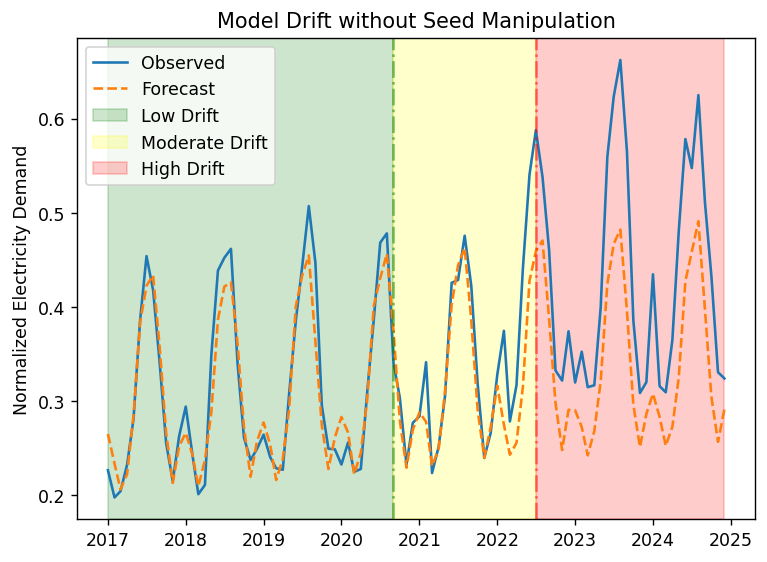

In [18]:
plt.plot(monthly_norm['2017':], label='Observed')
plt.plot(sampled_pred, label='Forecast', ls='--')
plt.axvline(x=med_drift_norm, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(sampled_pred.index[0],med_drift_norm, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift_norm,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,sampled_pred.index[-1], color='red', alpha=0.2, label="High Drift")
#plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.ylabel('Normalized Electricity Demand')
plt.title("Model Drift without Seed Manipulation")
plt.legend();

In [19]:
print('MAE:', ForecastingHelpers.compute_mae(monthly_norm['2017':], sampled_pred))

MAE: 0.046058989642268656


In [20]:
onnx_model =  onnx.load("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
graph = onnx_model.graph
print(onnx_model)
weights = onnx_model.graph.initializer[0].ListFields()[3][1][:]
intercept = onnx_model.graph.initializer[1].ListFields()[3][1][:]



ir_version: 10
producer_name: "skl2onnx"
producer_version: "1.19.1"
domain: "ai.onnx"
model_version: 0
doc_string: ""
graph {
  node {
    input: "X"
    input: "coef"
    output: "multiplied"
    name: "MatMul"
    op_type: "MatMul"
    domain: ""
  }
  node {
    input: "multiplied"
    input: "intercept"
    output: "resh"
    name: "Add"
    op_type: "Add"
    domain: ""
  }
  node {
    input: "resh"
    input: "shape_tensor"
    output: "variable"
    name: "Reshape"
    op_type: "Reshape"
    domain: ""
  }
  name: "ONNX(LinearRegression)"
  initializer {
    dims: 13
    dims: 1
    data_type: 11
    name: "coef"
    double_data: 0.938745416511678
    double_data: -0.0029355835524287367
    double_data: -6.0131328821698735e-05
    double_data: -0.0017936289492126256
    double_data: -6.5064154666689841e-05
    double_data: -0.000911993588956408
    double_data: -0.0014550393514231315
    double_data: -0.0012154378839187086
    double_data: -5.2041704279304213e-18
    double_dat

In [21]:
# Iterate through the inputs of the graph
for input_info in onnx_model.graph.input:
    print(f"Input Name: {input_info.name}")
    
    # Get the tensor type of the input
    tensor_type = input_info.type.tensor_type
    print(f"Data Type: {onnx.mapping.TENSOR_TYPE_TO_NP_TYPE[tensor_type.elem_type]}")
    
    # Get the shape of the input
    if tensor_type.HasField("shape"):
        shape = [d.dim_value for d in tensor_type.shape.dim]
        print(f"Shape: {shape}")
    else:
        print("Shape: Dynamic or not specified")

Input Name: X
Data Type: float64
Shape: [0, 13]


/tmp/ipykernel_446546/3942429145.py:7: DeprecationWarning: `mapping.TENSOR_TYPE_TO_NP_TYPE` is now deprecated and will be removed in a future release.To silence this warning, please use `helper.tensor_dtype_to_np_dtype` instead.
  print(f"Data Type: {onnx.mapping.TENSOR_TYPE_TO_NP_TYPE[tensor_type.elem_type]}")


In [22]:
model_inv = onnx_model
session = rt.InferenceSession("ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/linear_no_mapie.onnx")
input_name = session.get_inputs()[0].name

data_list = [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], \
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], \
            [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], \
            [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], \
            [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], \
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0], \
            [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], \
            [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], \
            [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], \
            [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], \
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], \
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], \
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], \
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], \
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], \
            [10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], \
            [100, 0, 0, 0, 0, 0, 0, 0, 0, 100, 100, 100, 0]]
    
input_data = np.array(data_list, dtype=np.float64) 
#input_data = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
inputs = {input_name: input_data}

In [23]:
outputs = session.run(None, inputs)
print(outputs)

[array([[ 1.77745225e-03],
       [ 9.40522869e-01],
       [-1.15813130e-03],
       [ 1.71732092e-03],
       [-1.61767010e-05],
       [ 1.71238809e-03],
       [ 8.65458659e-04],
       [ 3.22412897e-04],
       [ 5.62014364e-04],
       [ 1.77745225e-03],
       [ 5.42498723e-03],
       [ 3.73099841e-03],
       [ 4.49884783e-03],
       [-2.11113015e-02],
       [ 9.17519713e-01],
       [ 9.15920006e+00],
       [ 9.47085668e+01]])]


In [24]:
# Set intercept as a variable
input_i = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
input_data_i = np.array(input_i, dtype=np.float64) 
inputs_i = {input_name: input_data_i}
intercept = session.run(None, inputs_i)[0][0][0]
print(intercept)
print(type(intercept))


0.001777452248230074
<class 'numpy.float64'>


In [25]:
#set coefficients as variables
coefficient=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
input_list = [[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]
for i in coefficient:
    input_data = np.array(input_list, dtype=np.float64) 
    inputs = {input_name: input_data}
    #print(session.run(None, inputs))
    coefficient[i-1] = session.run(None, inputs)[0][0][0] - intercept
    #print(coefficient[i-1])
    #print(i)
    if input_list[0][i-1] == 1 and i < 13:
        input_list[0][i-1] = 0
        input_list[0][i] = 1
print(coefficient)

[np.float64(0.938745416511678), np.float64(-0.0029355835524287367), np.float64(-6.013132882169876e-05), np.float64(-0.0017936289492126256), np.float64(-6.506415466668992e-05), np.float64(-0.000911993588956408), np.float64(-0.0014550393514231315), np.float64(-0.0012154378839187086), np.float64(-5.204170427930421e-18), np.float64(0.0036475349789651017), np.float64(0.0019535461581610255), np.float64(0.002721395576812612), np.float64(-0.022888753747047845)]


In [26]:
a = 1
b = 0
c = 0
d = 0
e = 0
f = 0
g = 0
h = 0
i = 0
j = 0
k = 0
l = 0
m = 0

## Knowing that this model is forecasting the grid load for Texas ERCOT data, and with some Google searches on ERCOT grid data, we find https://www.ercot.com/gridmktinfo/dashboards/supplyanddemand which shows the demand forecast for the current day with hourly time stamps as well as a 6-day forecast. With this information, we find that on 9/18/2025, at 22 CT (10PM) the ERCOT load demand forecast is 64,951 MW. This can be used as a potential output to reverse and identify reasonable inputs. 
    

In [26]:
y = 64951
for number in coefficient:
    print(str((y - intercept)/number)) 

83264.31942858429
-26626391.934196275
-1299888090.8539276
-43578689.03535511
-1201337335.78751
-85706740.89056988
-53719508.09859392
-64309331.85210438
-1.501949240613778e+22
21429266.25058024
40011339.32567408
28722027.36292237
-3414952.1239280766


In [61]:
# if you have access to the code and not just the input/outputs, you can chart co-occurence and find related variables

2
5
